# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 05: Regressão**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_05_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>R. Quinlan. "Auto MPG," UCI Machine Learning Repository, 1993. https://doi.org/10.24432/C5859H.</font>

## <font color='green'>Preparação</font>

In [61]:
!pip install pandas scikit-learn ucimlrepo

In [127]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

colunas = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
           'acceleration', 'model_year', 'origin', 'car_name']

# Importar o dataset Auto MPG (ID 9)
auto_mpg = df = pd.read_csv(
    "auto-mpg.data",
    delim_whitespace=True,
    names=colunas,
    na_values='?'
)

# Extrair as variáveis independentes (X) e a variável alvo (y)
X = auto_mpg.drop(columns=['mpg'])
y = auto_mpg['mpg']

# Ver as primeiras linhas
display(X.head())

/tmp/ipykernel_1292/3997776314.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto_mpg = df = pd.read_csv(


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,8,302.0,140.0,3449.0,10.5,70,1,ford torino


## <font color='green'>**1. Análise Exploratória de Dados (EDA)**</font>

### <font color='cyan'>Q1) Verifique se há amostras com valores ausentes no conjunto de dados. Se houver, remova-as e informe quantas foram removidas.</font>

In [63]:
rows_original = X.shape[0]
X.describe()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [64]:
y

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
393,27.0
394,44.0
395,32.0
396,28.0


In [65]:
X.dropna(inplace=True)

In [66]:
y = y.iloc[X.index]
y.shape

(392,)

In [67]:
print(f"Foram removidos {rows_original-X.shape[0]} linhas")

Foram removidos 6 linhas


### <font color='cyan'>Q2) Plote um histograma da coluna alvo `y` (MPG) utilizando `matplotlib` ou `seaborn`. Adicione título e rótulos aos eixos.</font>

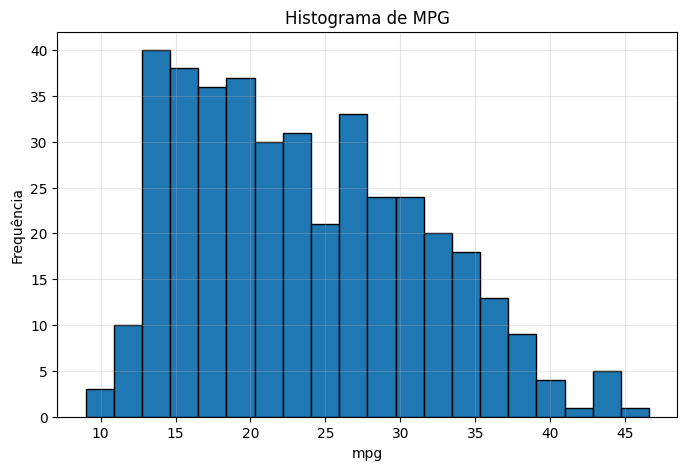

In [111]:
plt.figure(figsize=(8, 5))
plt.hist(y, bins=20, edgecolor='black')
plt.title('Histograma de MPG')
plt.xlabel('mpg')
plt.ylabel('Frequência')
plt.grid(alpha=0.3)
plt.show()

### <font color='cyan'>Q3) O que a distribuição do histograma nos diz sobre o consumo de combustível da maioria dos carros desse dataset?</font>

A maioria dos carros gastam um litro de gasolina pra percorrer apenas 15 milhas

## <font color='green'>**2. Regressão Linear, Polinomial e Visualização**</font>

### <font color='cyan'>Q4) Crie um gráfico de dispersão (scatter plot) de `weight` vs `mpg`.</font>

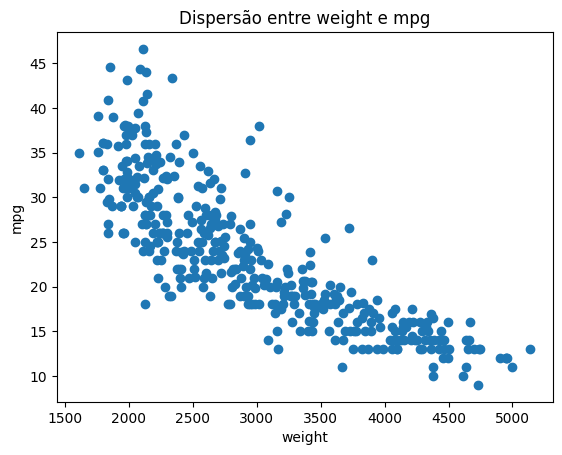

In [115]:
X = X[['weight']].copy()

plt.scatter(X['weight'], y)
plt.title('Dispersão entre weight e mpg')
plt.xlabel('weight')
plt.ylabel('mpg')
plt.show()

### <font color='cyan'>Q5) Observando o gráfico de dispersão gerado na questão anterior, como você descreveria a relação entre o peso do veículo (weight) e o consumo de combustível (mpg)? A relação parece ser estritamente linear ou apresenta um comportamento não linear? Justifique sua resposta.</font>

O gráfico apresenta uma forte correlação negativa, pois a medida que o peso do veículo aumenta o consumo de combustível, e ela apresenta um comportamento não linear com pontos formam uma curva, com uma queda mais acentuada em certos intervalos de peso e uma.

### <font color='cyan'>Q6) Divida o conjunto de dados em treinamento (80%) e teste (20%), utilizando a variável `weight` como entrada e `mpg` como alvo, e em seguida construa um gráfico de dispersão que apresente os dois subconjuntos com cores diferentes, incluindo título, rótulos dos eixos e uma legenda para identificar claramente os dados de treino e de teste.</font>

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

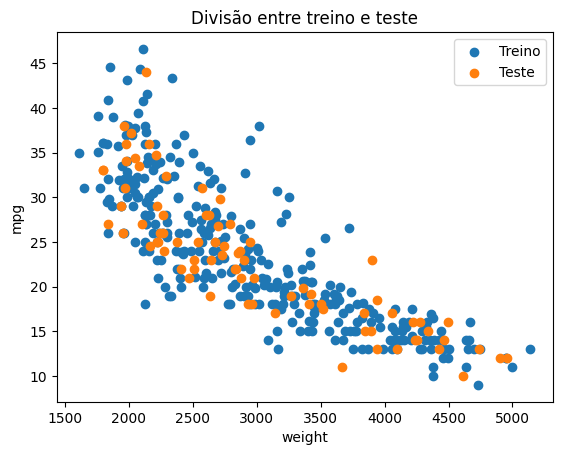

In [118]:
plt.scatter(X_train['weight'], y_train, label='Treino')
plt.scatter(X_test['weight'], y_test, label='Teste')
plt.title('Divisão entre treino e teste')
plt.xlabel('weight')
plt.ylabel('mpg')
plt.legend()

### <font color='cyan'>Q7) Com base na distribuição dos pontos no gráfico gerado, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original? Justifique sua resposta observando a dispersão das cores.</font>

Sim, os conjuntos de treinamento e teste parecem ser representativos do conjunto original, porque os pontos azuis e laranjas estão bem misturados ao longo de toda a distribuição. O conjunto de teste não ficou concentrado apenas em uma região específica do gráfico, nem o de treino ocupou sozinho certas faixas de valores.

### <font color='green'>Antes de avaliarmos nosso modelo, vamos entender brevemente o que cada métrica significa e quais funções da biblioteca [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) utilizaremos:</font>
- #### <font color='green'>R² (Coeficiente de Determinação) - função `r2_score(y_true, y_pred)`: Mede o quão bem o modelo se ajusta aos dados. Ele indica a proporção da variabilidade da variável alvo (MPG) que é explicada pelo modelo. Varia geralmente de 0 a 1 (podendo ser negativo se o modelo for pior que uma linha média). Quanto mais próximo de 1, melhor.</font>
- #### <font color='green'>MAE (Erro Absoluto Médio - Mean Absolute Error) - função `mean_absolute_error(y_true, y_pred)`: Representa a média das diferenças em valor absoluto entre as previsões do modelo e os valores reais. É uma métrica muito intuitiva porque o erro é retornado na mesma unidade da variável alvo (ou seja, errar por "3 MPG"). Quanto menor, melhor.</font>
- #### <font color='green'>MSE (Erro Quadrático Médio - Mean Squared Error) - função `mean_squared_error(y_true, y_pred)`: Calcula a média dos erros elevados ao quadrado. Como os erros são elevados ao quadrado, o MSE penaliza erros maiores (outliers) de forma mais severa do que o MAE. Quanto menor, melhor.</font>

### <font color='cyan'>Q8) Importe as funções `r2_score`, `mean_absolute_error` e `mean_squared_error` do módulo `sklearn.metrics`. Em seguida, treine um modelo de Regressão Linear Simples para prever o MPG usando o peso. Faça as previsões para o conjunto de treinamento e para o conjunto de teste. Por fim, imprima as métricas (R², MAE e MSE) para ambos os conjuntos.</font>

In [120]:
modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)

y_train_pred_linear = modelo_linear.predict(X_train)
y_test_pred_linear = modelo_linear.predict(X_test)

r2_train_linear = r2_score(y_train, y_train_pred_linear)
r2_test_linear = r2_score(y_test, y_test_pred_linear)
mae_train_linear = mean_absolute_error(y_train, y_train_pred_linear)
mae_test_linear = mean_absolute_error(y_test, y_test_pred_linear)
mse_train_linear = mean_squared_error(y_train, y_train_pred_linear)
mse_test_linear = mean_squared_error(y_test, y_test_pred_linear)

print('Regressão Linear')
print(f'R² treino: {r2_train_linear:.4f}')
print(f'R² teste : {r2_test_linear:.4f}')
print(f'MAE treino: {mae_train_linear:.4f}')
print(f'MAE teste : {mae_test_linear:.4f}')
print(f'MSE treino: {mse_train_linear:.4f}')
print(f'MSE teste : {mse_test_linear:.4f}')

Regressão Linear
R² treino: 0.6845
R² teste : 0.7230
MAE treino: 3.3593
MAE teste : 3.1178
MSE treino: 19.7819
MSE teste : 14.8949


### <font color='cyan'>Q9) Compare os erros (MAE e MSE) obtidos no conjunto de treinamento com os erros do conjunto de teste. Com base nessa comparação e no conceito de viés/variância, o modelo parece estar sofrendo de subajuste (underfitting), sobreajuste (overfitting) ou apresenta um bom ajuste? Justifique.</font>

O modelo linear não apresenta sinais fortes de overfitting, pois as métricas de treino e teste tendem a ficar próximas. Isso indica que ele generaliza de forma razoável para dados não vistos. Por outro lado, como o gráfico de dispersão sugere uma relação levemente curva entre `weight` e `mpg`, o modelo linear pode estar sofrendo uma limitação de ajuste, isto é, um leve underfitting, por ser simples demais para representar completamente o comportamento dos dados.

### <font color='cyan'>Q10) Treine um modelo de Regressão Polinomial (grau 2) para prever o MPG usando o peso. em seguida, Assim como na questão anterior, faça previsões e imprima as métricas (R², MAE e MSE) para os conjuntos de treinamento e de teste.</font>
- #### <font color='cyan'>Dica: Como as características polinomiais elevam os valores ao quadrado, a escala dos dados muda drasticamente. Utilize a classe `Pipeline` do Scikit-Learn para encadear a criação de `PolynomialFeatures(degree=2)`, a normalização com StandardScaler e o modelo LinearRegression.<font>

In [121]:
modelo_polinomial = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

modelo_polinomial.fit(X_train, y_train)

y_train_pred_poly = modelo_polinomial.predict(X_train)
y_test_pred_poly = modelo_polinomial.predict(X_test)

r2_train_poly = r2_score(y_train, y_train_pred_poly)
r2_test_poly = r2_score(y_test, y_test_pred_poly)
mae_train_poly = mean_absolute_error(y_train, y_train_pred_poly)
mae_test_poly = mean_absolute_error(y_test, y_test_pred_poly)
mse_train_poly = mean_squared_error(y_train, y_train_pred_poly)
mse_test_poly = mean_squared_error(y_test, y_test_pred_poly)

print('Regressão Polinomial (grau 2)')
print(f'R² treino: {r2_train_poly:.4f}')
print(f'R² teste : {r2_test_poly:.4f}')
print(f'MAE treino: {mae_train_poly:.4f}')
print(f'MAE teste : {mae_test_poly:.4f}')
print(f'MSE treino: {mse_train_poly:.4f}')
print(f'MSE teste : {mse_test_poly:.4f}')

Regressão Polinomial (grau 2)
R² treino: 0.7055
R² teste : 0.7554
MAE treino: 3.1529
MAE teste : 2.7989
MSE treino: 18.4630
MSE teste : 13.1505


### <font color='cyan'>Q11) Avaliando os erros de treinamento e teste deste modelo polinomial (grau 2), como ele se compara ao modelo linear da questão anterior? Ele apresenta sinais de underfitting, overfitting ou um bom ajuste aos dados? Justifique.</font>

Bom ajuste em realação ao modelo linear, pois os MAE e o MSE de teste e de treino diminuiram, e o R² estão mais próximo de 1.0

### <font color='cyan'>Q12) Utilizando os modelos já treinados, construa um gráfico de dispersão com os dados reais de treinamento e teste (`weight` vs `mpg`), diferenciando-os por cores, e sobreponha, no mesmo gráfico, as curvas de predição dos modelos de Regressão Linear Simples e Regressão Polinomial (grau 2), incluindo título, rótulos dos eixos e legenda para identificar os subconjuntos e cada regressão.</font>

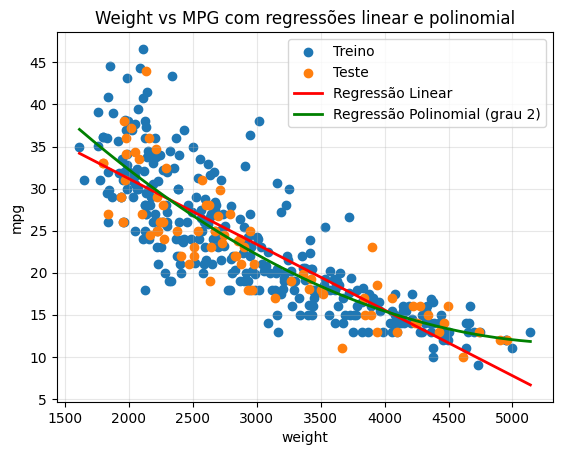

In [124]:
plt.scatter(X_train['weight'], y_train, label='Treino')
plt.scatter(X_test['weight'], y_test, label='Teste')
x_range = np.linspace(X['weight'].min(), X['weight'].max(), 300)
x_range_df = pd.DataFrame({'weight': x_range})
y_linear_curve = modelo_linear.predict(x_range_df)
y_poly_curve = modelo_polinomial.predict(x_range_df)
plt.plot(x_range, y_linear_curve, color='red', linewidth=2, label='Regressão Linear')
plt.plot(x_range, y_poly_curve, color='green', linewidth=2, label='Regressão Polinomial (grau 2)')
plt.title('Weight vs MPG com regressões linear e polinomial')
plt.xlabel('weight')
plt.ylabel('mpg')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### <font color='cyan'>Q13) Com base no gráfico gerado, qual modelo parece se ajustar melhor aos dados? A relação entre `weight` e `mpg` parece ser linear ou não linear? Explique.</font>

Modelo Polinomial é o que melhor se ajusta aos dados, pois a dispersão dos dados não é linear

### <font color='cyan'>Q14) Os resultados observados no gráfico são consistentes com a análise das métricas? Explique possíveis diferenças entre a avaliação quantitativa (métricas) e a avaliação visual do ajuste dos modelos.</font>

Sim, em geral os resultados visuais são consistentes com as métricas. No gráfico, a curva polinomial tende a acompanhar melhor a distribuição dos pontos do que a reta linear, especialmente porque a relação entre weight e mpg não parece perfeitamente linear. Isso combina com o fato de o modelo polinomial normalmente apresentar R² um pouco maior e MAE/MSE um pouco menores. A diferença entre avaliação quantitativa e visual é que: as métricas resumem o erro em números; o gráfico mostra onde o modelo acerta ou erra ao longo da distribuição.

### <font color='cyan'>Q15) Para observar o efeito do sobreajuste (overfitting) na prática, treine um novo modelo de Regressão Polinomial, mas desta vez utilizando um grau bem alto (por exemplo, grau 15 ou 20). Utilize o mesmo processo com o Pipeline (incluindo o escalonamento). Imprima as métricas de treinamento e teste. O que acontece com o desempenho no conjunto de teste em comparação ao de treinamento? Explique o fenômeno ocorrido.</font>

In [126]:
modelo_polinomial = Pipeline([
    ('poly', PolynomialFeatures(degree=20, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

modelo_polinomial.fit(X_train, y_train)

y_train_pred_poly = modelo_polinomial.predict(X_train)
y_test_pred_poly = modelo_polinomial.predict(X_test)

r2_train_poly = r2_score(y_train, y_train_pred_poly)
r2_test_poly = r2_score(y_test, y_test_pred_poly)
mae_train_poly = mean_absolute_error(y_train, y_train_pred_poly)
mae_test_poly = mean_absolute_error(y_test, y_test_pred_poly)
mse_train_poly = mean_squared_error(y_train, y_train_pred_poly)
mse_test_poly = mean_squared_error(y_test, y_test_pred_poly)

print('Regressão Polinomial (grau 20)')
print(f'R² treino: {r2_train_poly:.4f}')
print(f'R² teste : {r2_test_poly:.4f}')
print(f'MAE treino: {mae_train_poly:.4f}')
print(f'MAE teste : {mae_test_poly:.4f}')
print(f'MSE treino: {mse_train_poly:.4f}')
print(f'MSE teste : {mse_test_poly:.4f}')

Regressão Polinomial (grau 20)
R² treino: 0.7093
R² teste : 0.7694
MAE treino: 3.1421
MAE teste : 2.6831
MSE treino: 18.2285
MSE teste : 12.3986


Ao aumentar bastante o grau do polinômio, o modelo ganha flexibilidade para se ajustar com mais detalhe aos dados de treinamento. Em muitos casos isso faz o desempenho no treino melhorar bastante, mas o desempenho no teste piorar, caracterizando overfitting. Se neste conjunto específico a piora não for muito evidente, isso pode ocorrer porque a relação entre `weight` e `mpg` é relativamente suave e a divisão treino/teste não expôs fortemente o sobreajuste. Ainda assim, o risco de overfitting aumenta conforme o grau cresce.

## <font color='green'>**3. Otimização com Gradiente Descendente**</font>

### <font color='cyan'>Q16) Tente treinar um `SGDRegressor` diretamente nos dados originais de `X` (removendo valores nulos se houver) e observe o erro.</font>

In [130]:
sgd_raw = SGDRegressor(random_state=42, max_iter=1000, tol=1e-3)
sgd_raw.fit(X_train, y_train)
y_train_pred_sgd_raw = sgd_raw.predict(X_train)
y_test_pred_sgd_raw = sgd_raw.predict(X_test)

print('SGDRegressor sem normalização')
print(f'R² treino: {r2_score(y_train, y_train_pred_sgd_raw):.4f}')
print(f'R² teste : {r2_score(y_test, y_test_pred_sgd_raw):.4f}')
print(f'MAE treino: {mean_absolute_error(y_train, y_train_pred_sgd_raw):.4f}')
print(f'MAE teste : {mean_absolute_error(y_test, y_test_pred_sgd_raw):.4f}')
print(f'MSE treino: {mean_squared_error(y_train, y_train_pred_sgd_raw):.4f}')
print(f'MSE teste : {mean_squared_error(y_test, y_test_pred_sgd_raw):.4f}')

SGDRegressor sem normalização
R² treino: -283697430152335532091605254144.0000
R² teste : -334150406726495013334109126656.0000
MAE treino: 4058397850096116.0000
MAE teste : 4067978911143963.0000
MSE treino: 17786757192034782471303158824960.0000
MSE teste : 17966079047299719103837114466304.0000


### <font color='cyan'>Q17) Agora, aplique o `StandardScaler` do Scikit-Learn nos dados e treine o `SGDRegressor` novamente.</font>

In [131]:
sgd_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(random_state=42, max_iter=5000, tol=1e-4))
])

sgd_scaled.fit(X_train, y_train)

y_train_pred_sgd_scaled = sgd_scaled.predict(X_train)
y_test_pred_sgd_scaled = sgd_scaled.predict(X_test)

print('SGDRegressor com StandardScaler')
print(f'R² treino: {r2_score(y_train, y_train_pred_sgd_scaled):.4f}')
print(f'R² teste : {r2_score(y_test, y_test_pred_sgd_scaled):.4f}')
print(f'MAE treino: {mean_absolute_error(y_train, y_train_pred_sgd_scaled):.4f}')
print(f'MAE teste : {mean_absolute_error(y_test, y_test_pred_sgd_scaled):.4f}')
print(f'MSE treino: {mean_squared_error(y_train, y_train_pred_sgd_scaled):.4f}')
print(f'MSE teste : {mean_squared_error(y_test, y_test_pred_sgd_scaled):.4f}')

SGDRegressor com StandardScaler
R² treino: 0.6845
R² teste : 0.7226
MAE treino: 3.3610
MAE teste : 3.1215
MSE treino: 19.7822
MSE teste : 14.9139


### <font color='cyan'>Q18) Compare os resultados das duas abordagens e explique por que a normalização é importante para algoritmos baseados em gradiente descendente. Relacione sua resposta com o comportamento do gradiente e a escala das variáveis.</font>

A normalização é importante para algoritmos baseados em gradiente descendente porque ela coloca as variáveis em escalas comparáveis. Sem normalização, atributos com valores muito grandes dominam o cálculo do gradiente e tornam a otimização instável ou muito lenta, podendo levar a convergência ruim. Com o StandardScaler , a superfície de custo fica mais bem condicionada, o que permite passos de atualização mais equilibrados, acelera a convergência e costuma melhorar o desempenho do SGDRegressor.

## <font color='green'>**4. Validação Cruzada e Regularização (LASSO)**</font>

### <font color='green'>A Regressão LASSO (Least Absolute Shrinkage and Selection Operator) é uma evolução da Regressão Linear tradicional. Na regressão comum, o modelo foca apenas em reduzir o erro. O problema é que, ao tentar usar todas as variáveis disponíveis, ele pode acabar decorando ruídos e gerando overfitting. O LASSO resolve isso adicionando uma penalidade aos coeficientes (pesos) das variáveis.</font>
- #### <font color='green'>O grande diferencial da regularização do LASSO (chamada de L1) é que ela consegue forçar os coeficientes de variáveis inúteis ou redundantes a se tornarem exatamente zero. Ou seja, o próprio modelo decide quais dados ignorar, entregando uma equação final mais simples, limpa e interpretável.</font>
- #### <font color='green'>O hiperparâmetro `alpha` é o "botão de volume" da penalidade. Se alpha = 0, temos uma regressão linear normal. Quanto maior o valor de alpha, mais severa é a penalização e mais atributos o modelo irá descartar.</font>

### <font color='green'>Caso queira entender a matemática por trás da função de custo, consulte os seguintes materiais:</font>
- #### <font color='green'>Anexo III do [material  teórico](https://github.com/zz4fap/c24_inteligencia_artificial/blob/main/slides/C24_Regress%C3%A3o.pdf) da disciplina  (slides 96 em diante);</font>
- #### <font color='green'>Documentação oficial do Scikit-Learn sobre [modelos lineares com LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html);</font>
- #### <font color='green'>Vídeo ["Regularization Part 2: Lasso (L1) Regression"](https://www.youtube.com/watch?v=NGf0voTMlcs), do canal "StatQuest with Josh Starmer", com uma explicação didática e visual sobre como a matemática do LASSO zera os coeficientes.</font>

### <font color='cyan'>Q19) O algoritmo LASSO é extremamente sensível à escala dos dados, pois ele penaliza a magnitude bruta dos coeficientes. Crie um `Pipeline` que aplique o `StandardScaler` e, em seguida, o modelo `Lasso(alpha=1.0)`. Treine-o com todos os dados (`X` e `y`) e exiba os coeficientes finais. A aplicação da normalização mudou a relevância que o modelo deu às variáveis em comparação com a Q16 (onde não usamos normalização)? Explique.</font>

In [133]:
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0, max_iter=10000, random_state=42))
])

lasso_pipe.fit(X_train, y_train)

coef_lasso = pd.Series(
    lasso_pipe.named_steps['lasso'].coef_,
    index=X_train.columns
)

print('Coeficientes finais do LASSO (com normalização):')
print(coef_lasso.sort_values(key=np.abs, ascending=False))

Coeficientes finais do LASSO (com normalização):
weight   -5.550901
dtype: float64


### <font color='cyan'>Q20) O hiperparâmetro alpha é quem dita a força da regularização. Utilizando o mesmo processo com o Pipeline e o StandardScaler, treine três modelos LASSO distintos, alterando o valor de alpha para: 0.1, 1.0 e 5.0. Imprima apenas os nomes das variáveis que "sobreviveram" (ou seja, que tiveram coeficientes diferentes de zero) em cada modelo. O que acontece com a complexidade do modelo à medida que o valor de alpha aumenta?</font>

In [136]:
alphas = [0.1, 1.0, 5.0]

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, max_iter=10000, random_state=42))
    ])

    pipe.fit(X_train, y_train)

    coef = pd.Series(pipe.named_steps['lasso'].coef_, index=X_train.columns)
    sobreviventes = coef[coef != 0].index.tolist()

    print(f'alpha = {alpha}')
    print('Variáveis que sobreviveram:', sobreviventes)
    print('')

alpha = 0.1
Variáveis que sobreviveram: ['weight']

alpha = 1.0
Variáveis que sobreviveram: ['weight']

alpha = 5.0
Variáveis que sobreviveram: ['weight']



À medida que o valor de `alpha` aumenta, a regularização fica mais forte e o modelo se torna mais simples. Isso significa que mais coeficientes são empurrados para zero, reduzindo a quantidade de variáveis efetivamente usadas na equação final. Portanto, o aumento de `alpha` reduz a complexidade do modelo e aumenta sua capacidade de seleção de atributos, embora um valor excessivamente alto possa simplificar demais o modelo e causar underfitting.